In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

import jax
import jax.numpy as jnp
import jax.random as jr

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


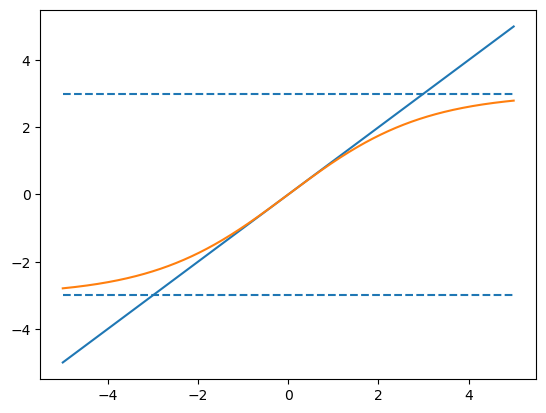

: 

In [ ]:
x = jnp.linspace(-5, 5, 1000)
from utils import tanh_clip
y = tanh_clip(x, 3.0)
import matplotlib.pyplot as plt
plt.plot(x, x)
plt.plot(x, tanh_clip(x, 3.0))
plt.hlines([-3.0, 3.0], -5, 5, linestyles='dashed')

# Setup Simulator

In [2]:
from systems import Cascade, faulty_actuators, faulty_sensors, as_faulty
from simulator  import Simulator

In [3]:
T = 100
sys = Cascade(x_dim=2, u_dim=2, y_dim=1, x_noise_std=0.0, y_noise_std=0.0)
sys = faulty_actuators(as_faulty(sys))
sim = Simulator(
    sys=sys,
    ref_y=jnp.ones((T, sys.y_dim)),
    ref_u=jnp.zeros((T, sys.u_dim)),
    ref_x=jnp.zeros((T, sys.x_dim)),
    t_fault=0.2,
    Jy=0.1 * jnp.eye(sys.y_dim),
    Ju=0.1 * jnp.eye(sys.u_dim),
    Jx=0.0 * jnp.eye(sys.x_dim),
    Jz=10.0 * jnp.eye(sys.z_dim),
    mpc_horizon=10,
    mpc_discount=1.0,
    mpc_integral_action=True,
    Q=0.01 * jnp.eye(sys.x_dim + sys.z_dim).at[: sys.z_dim, : sys.z_dim].multiply(0.01),
    R=0.01 * jnp.eye(sys.y_dim),
)

# Simulation without aux

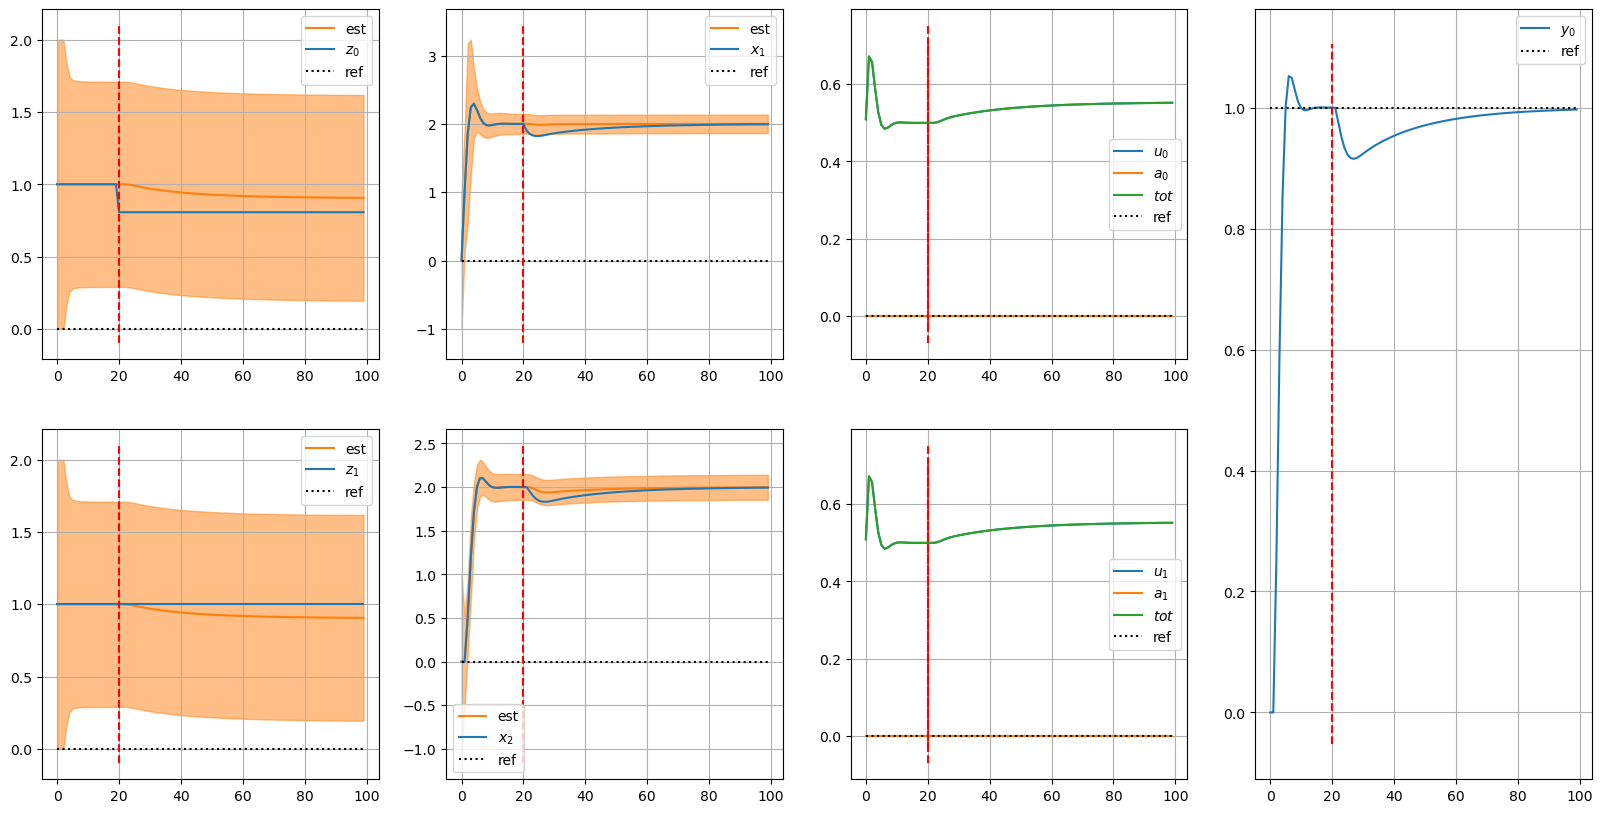

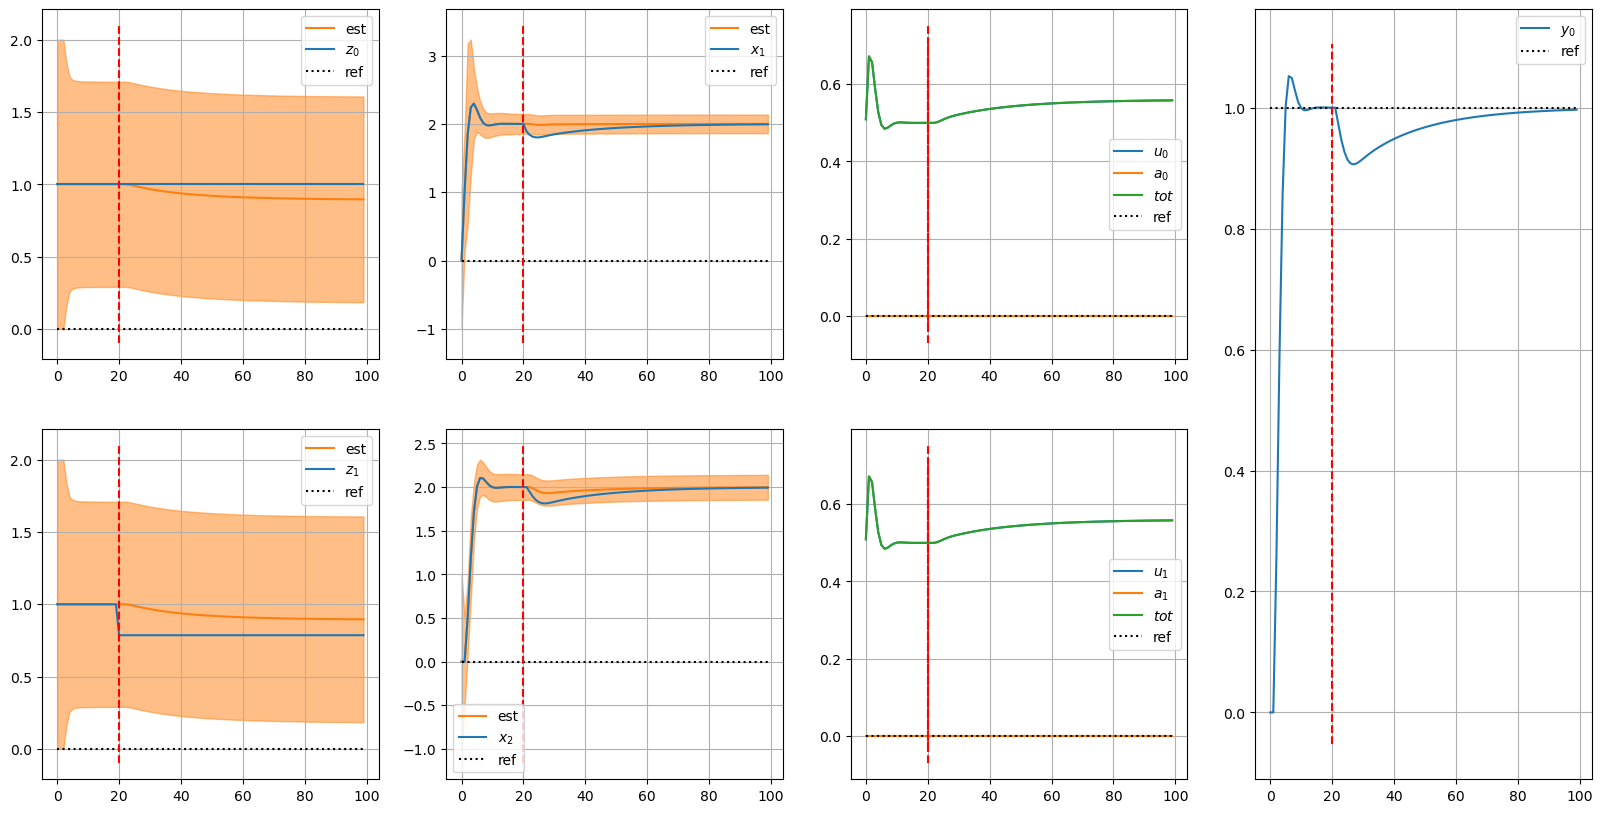

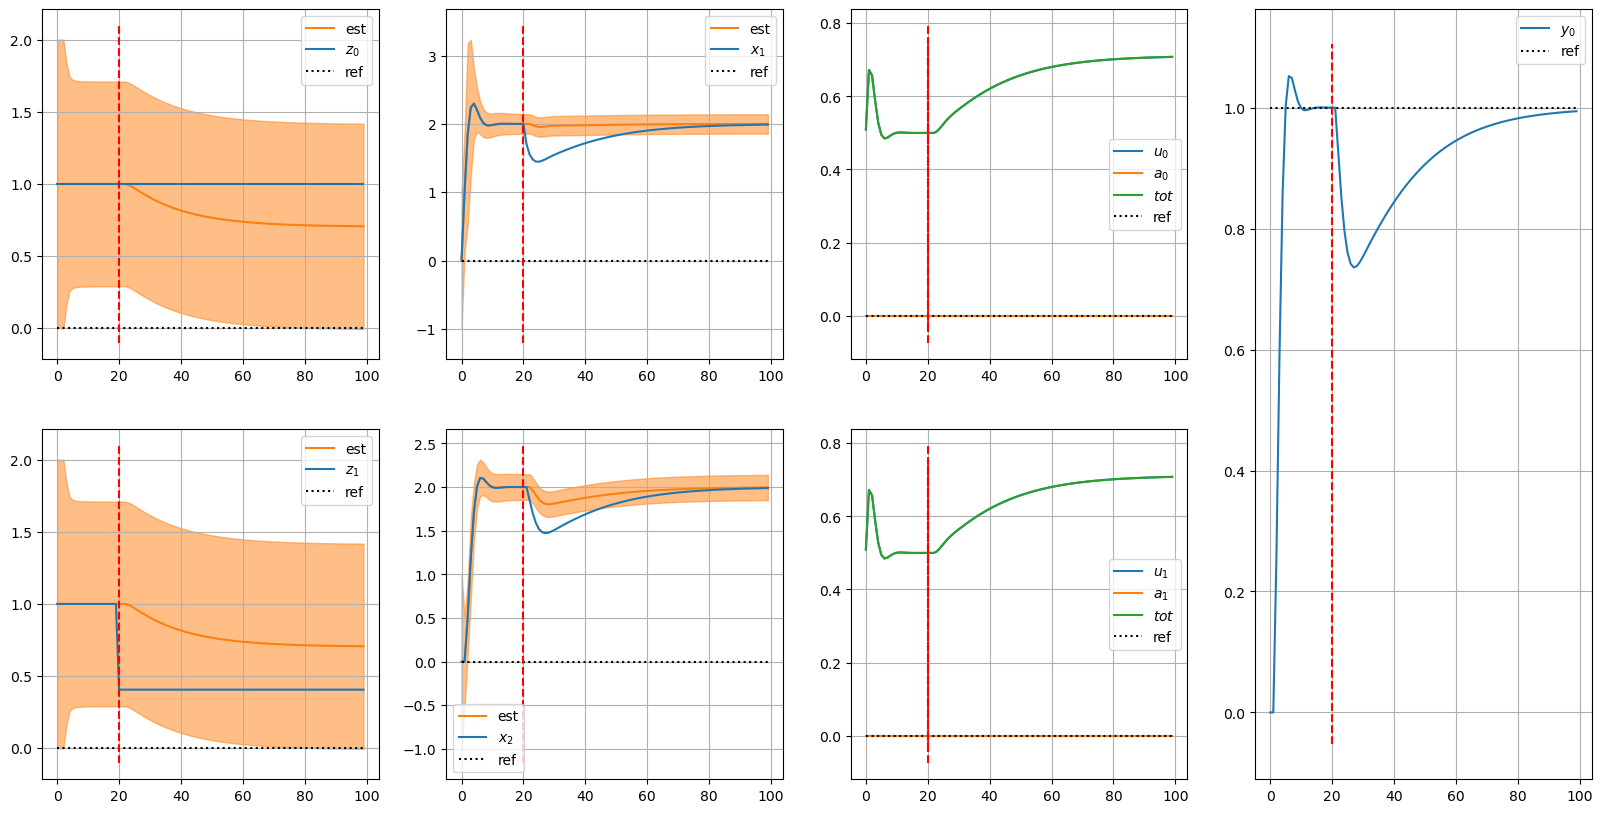

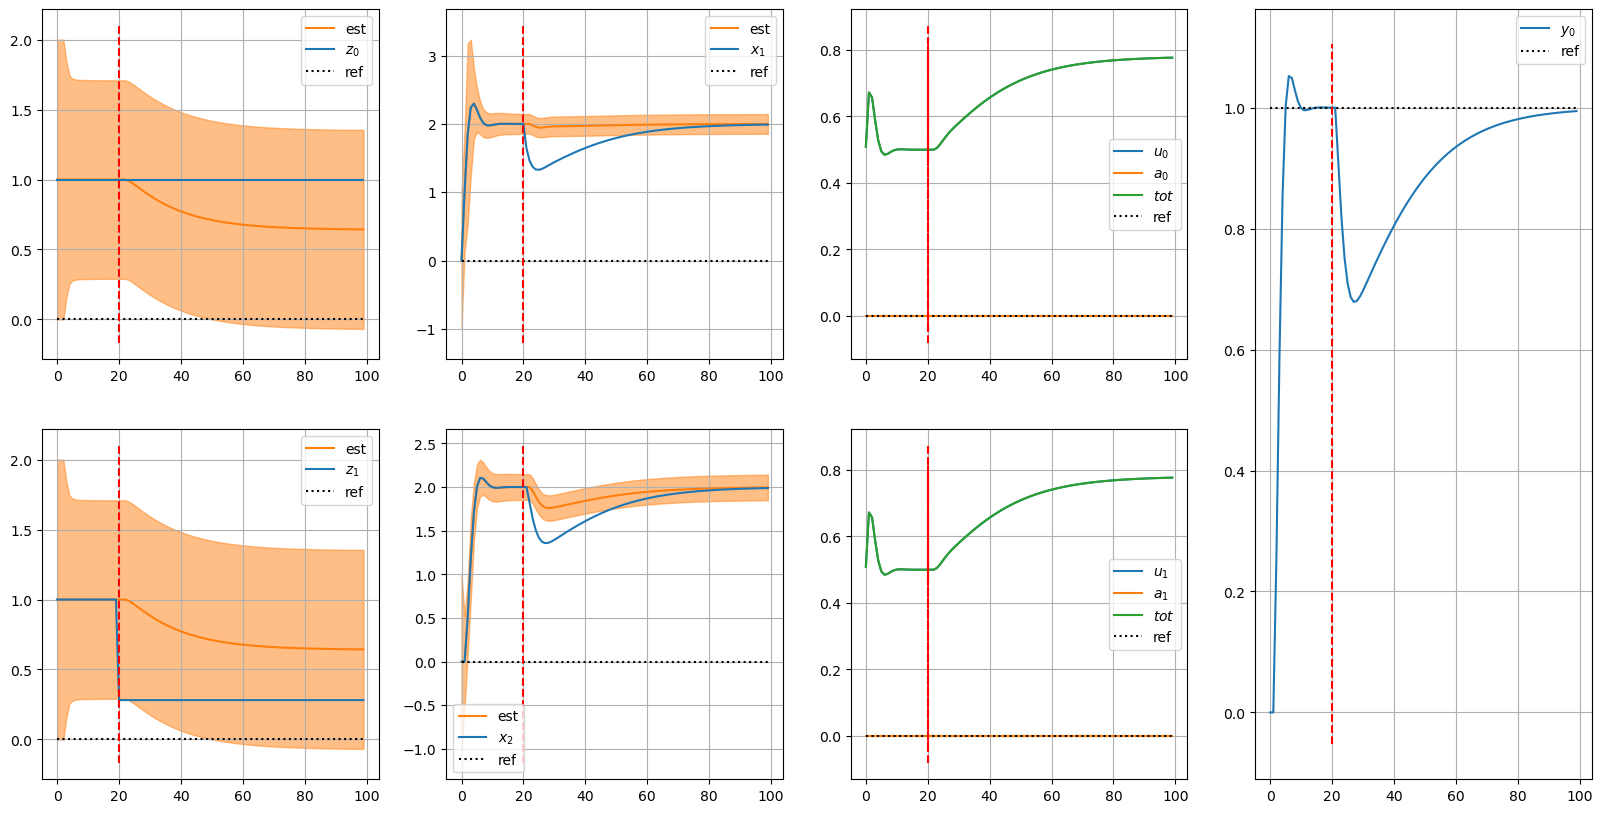

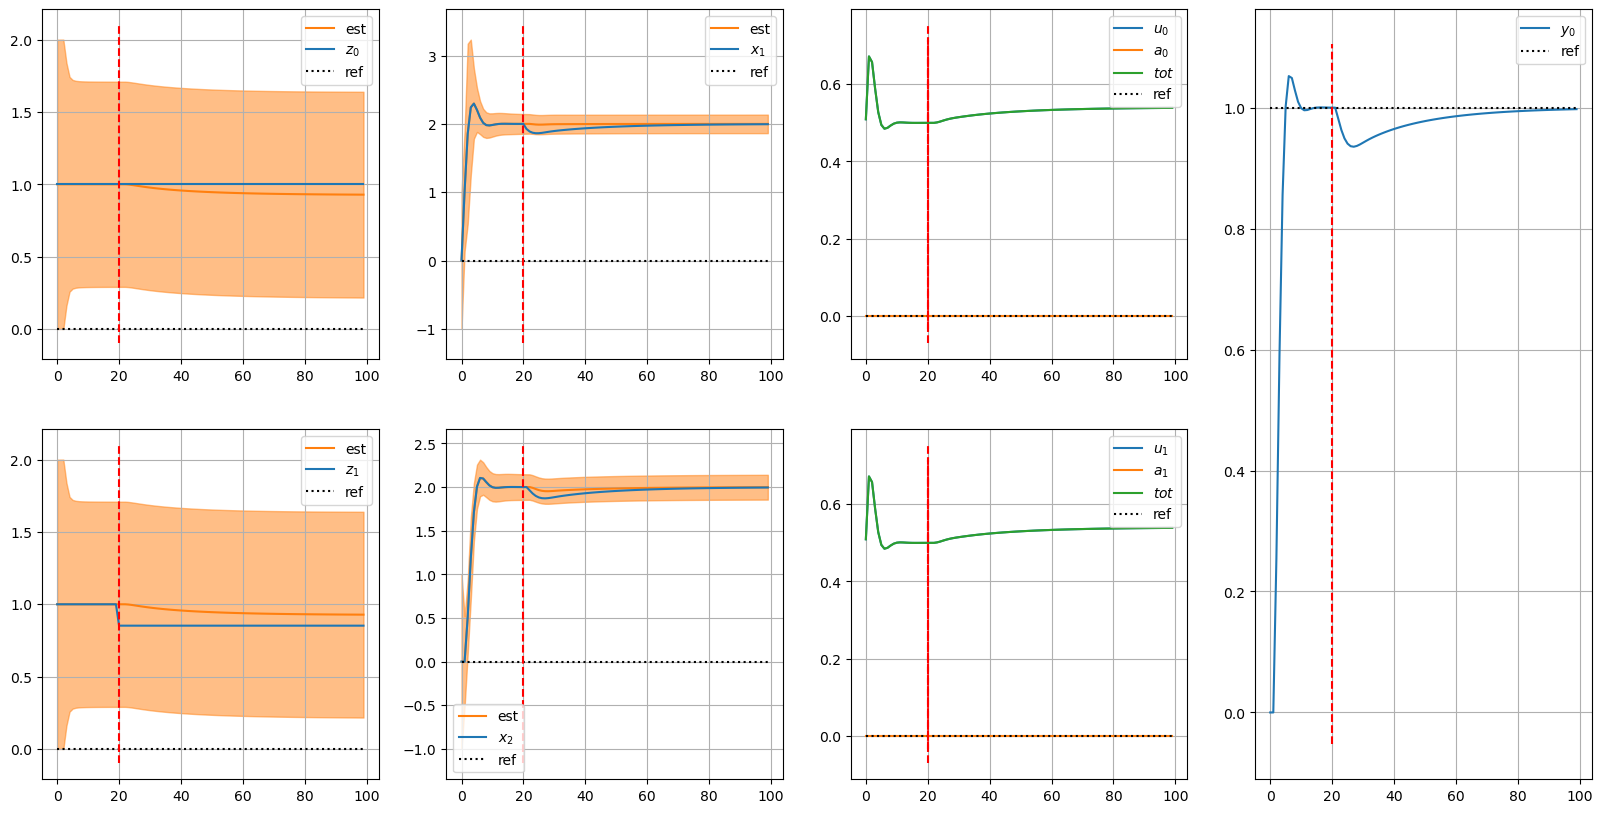

In [4]:
aux = lambda _, rng: (jnp.zeros(sys.u_dim), 0.0, None)
for seed in range(5):
    state, outs, rewards = sim.rollout(aux, rng=jr.key(seed))
    sim.plot(outs)

# Setup Policy

In [5]:
import ppo
from functools import partial

policy = ppo.Policy(sys.u_dim, discount=0.99)

0it [00:00, ?it/s]


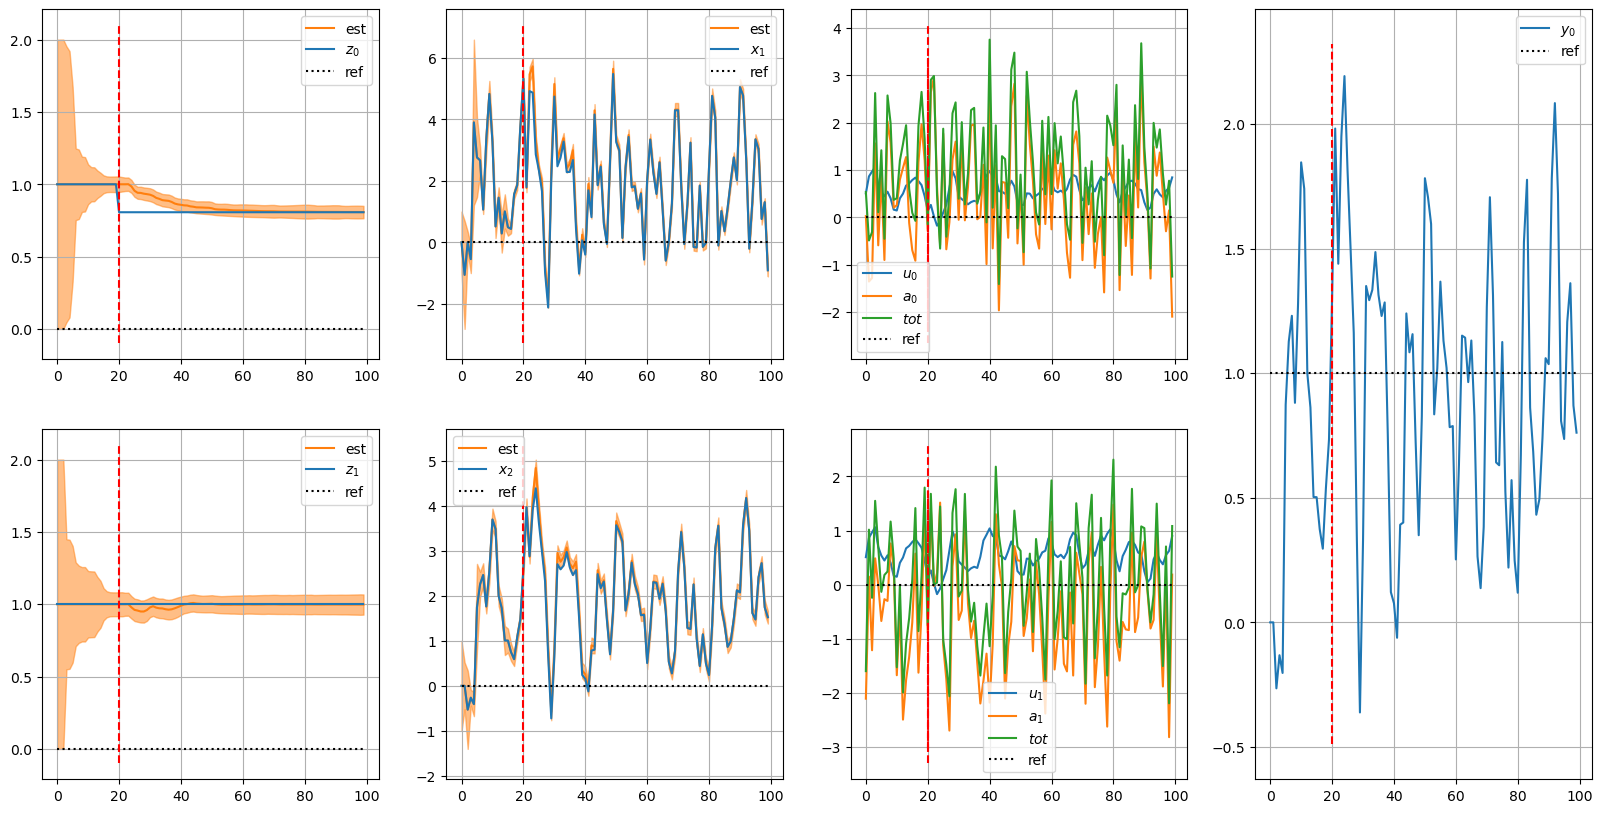

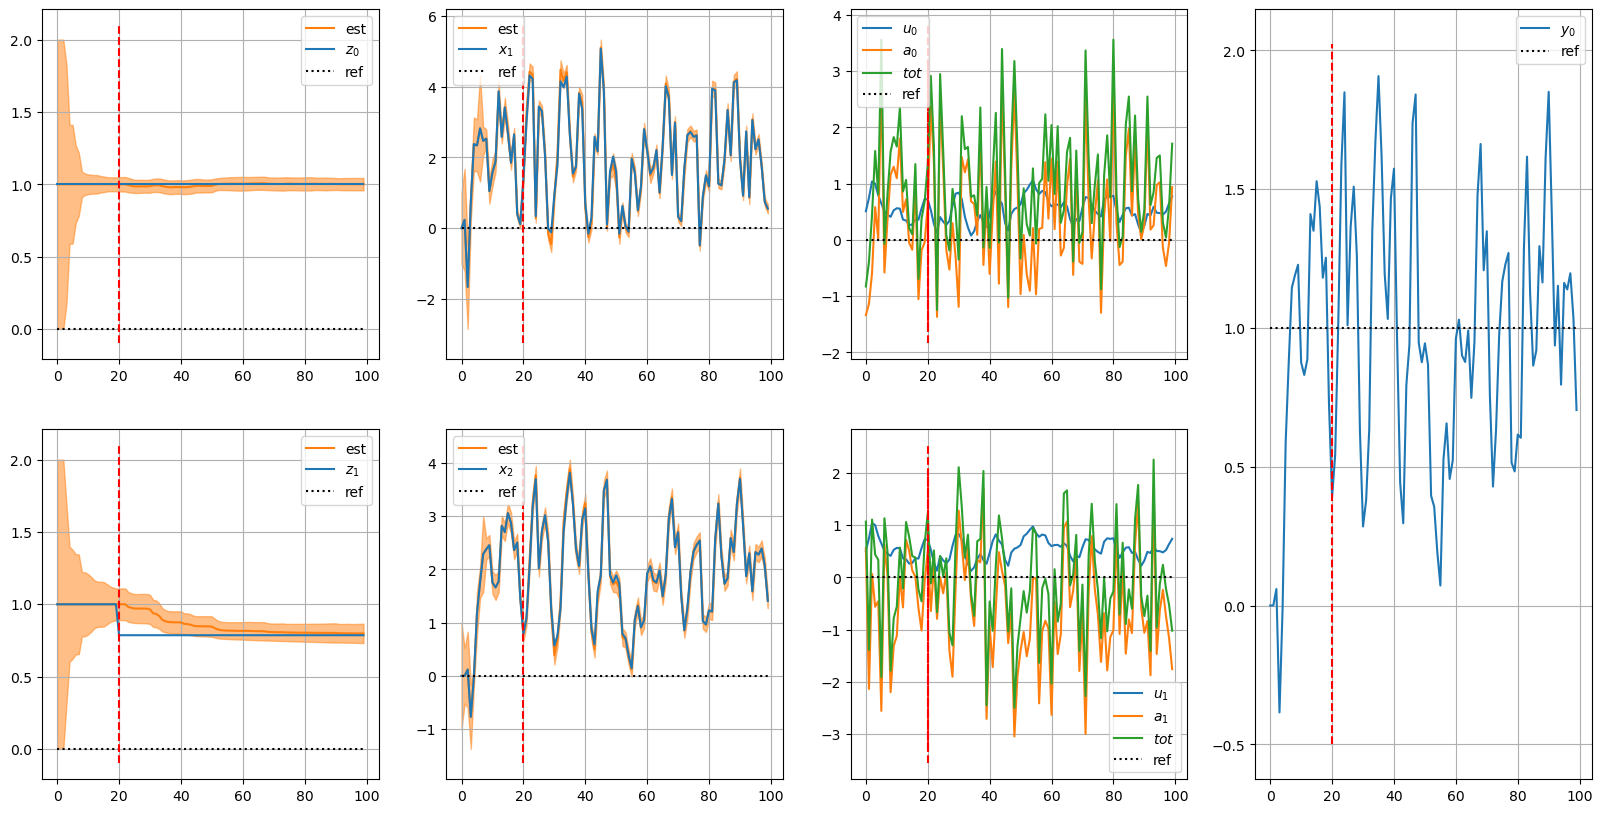

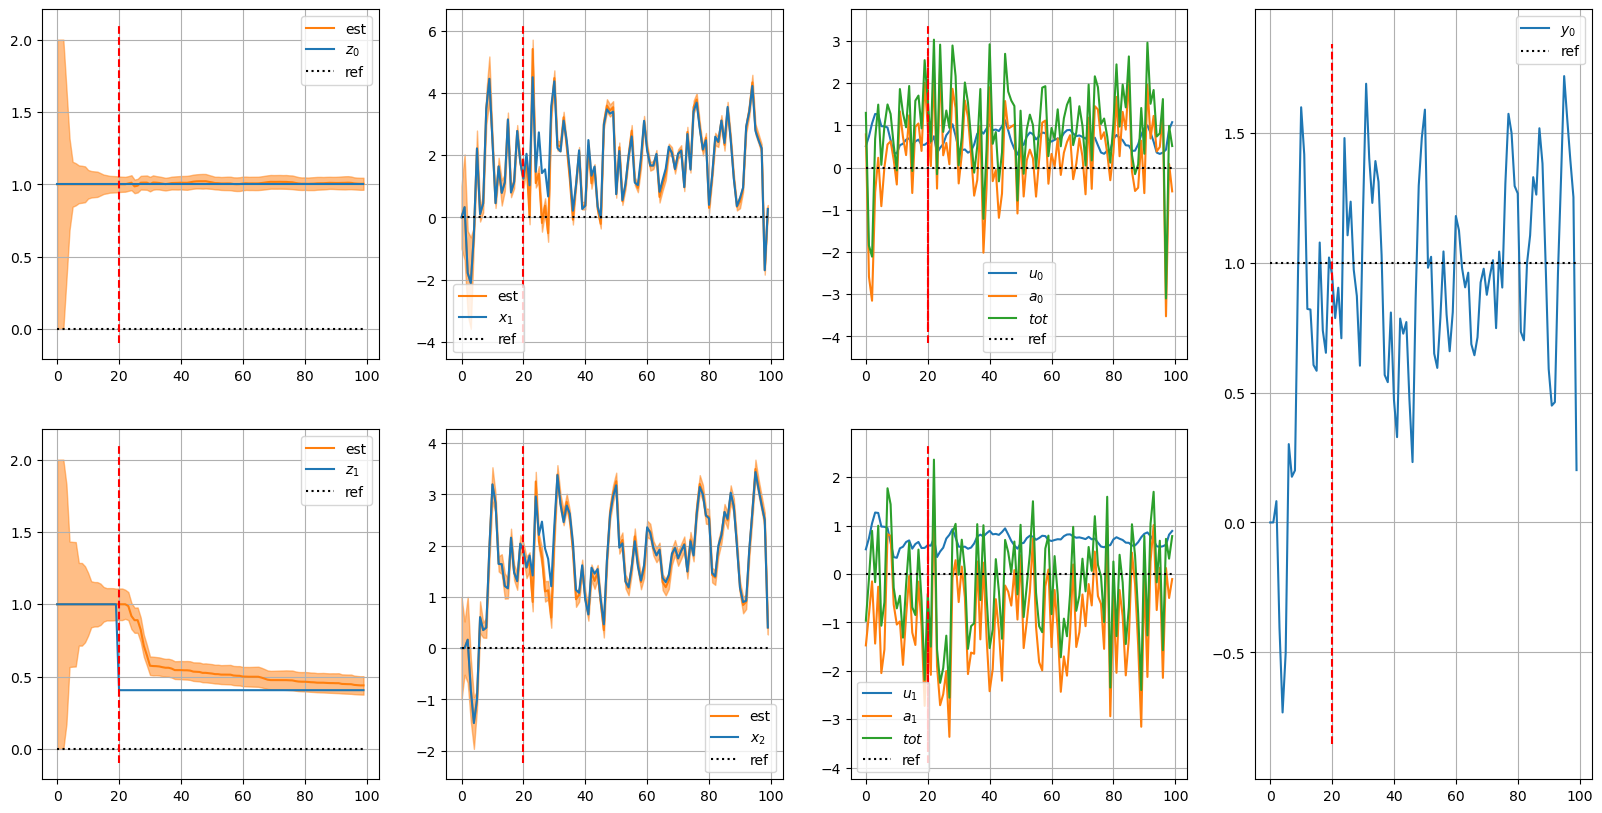

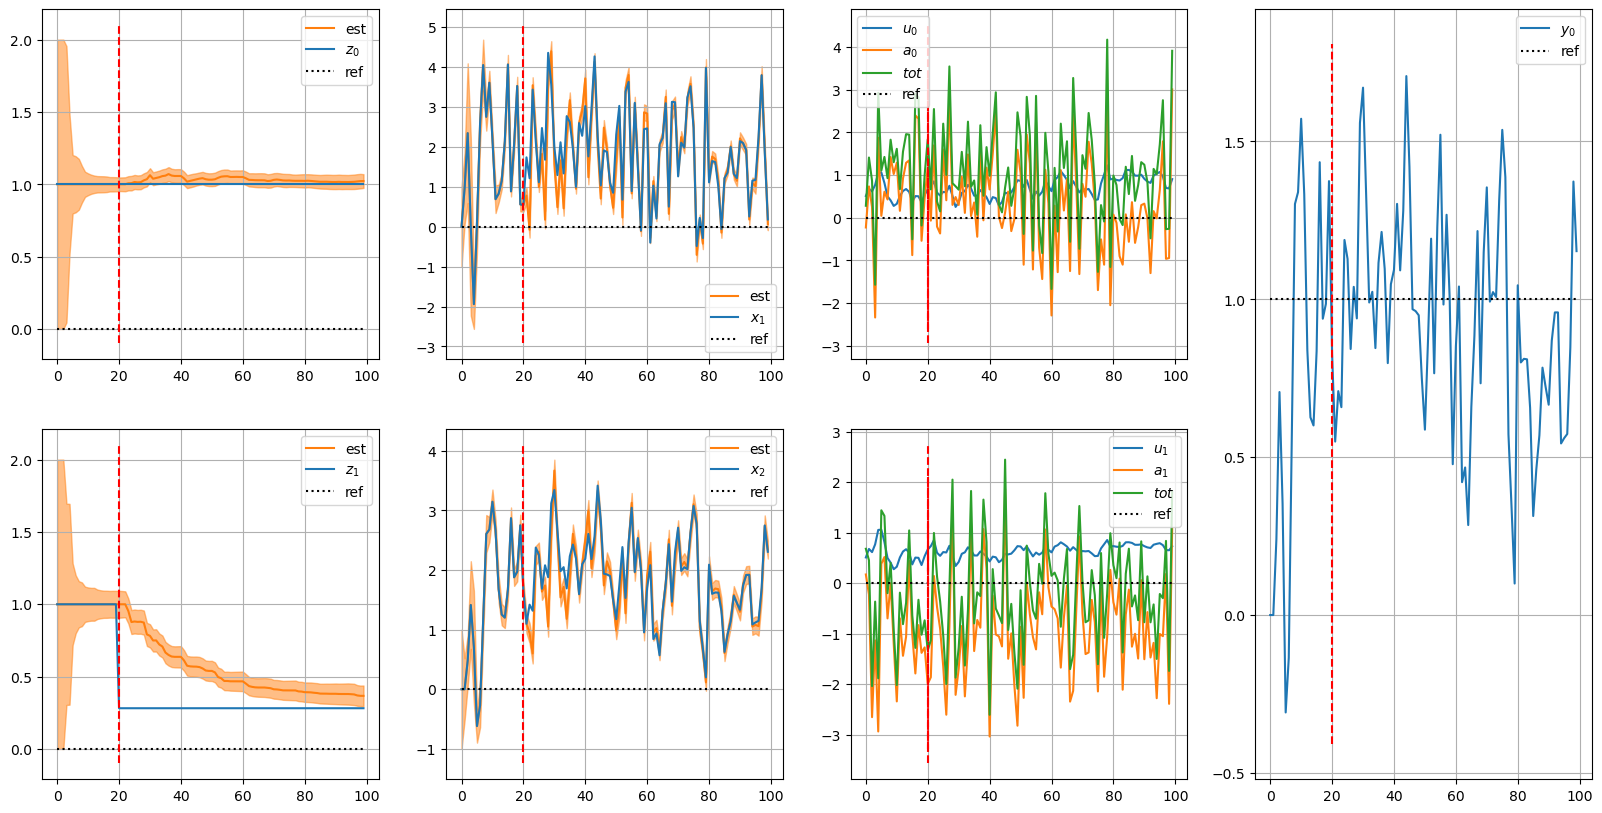

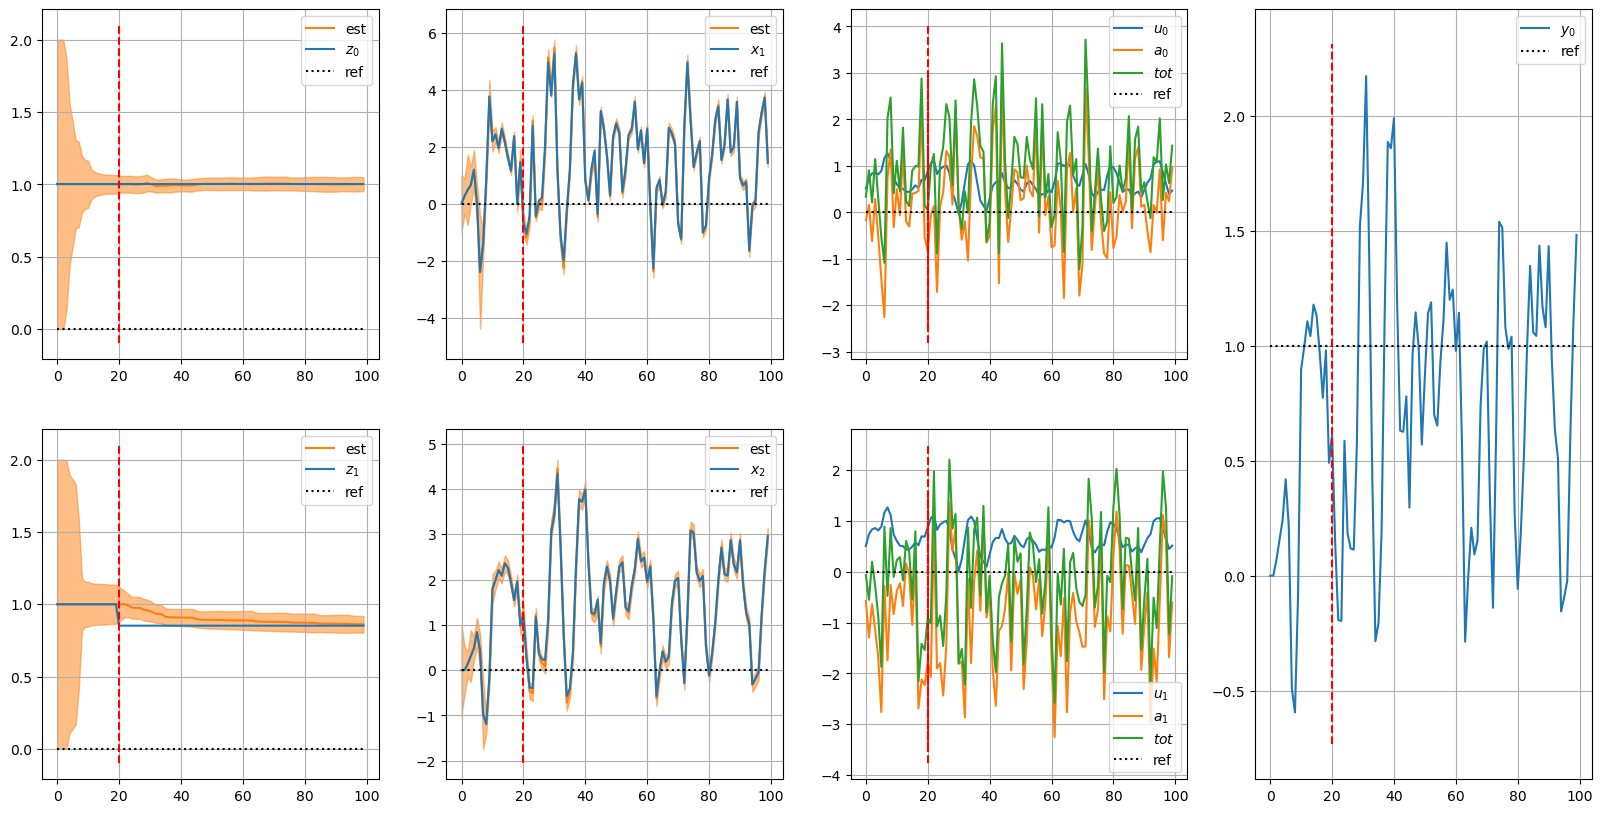

In [6]:
params, log_loss, log_rew = policy.optimize(sim, epochs=0)
aux = partial(policy.apply, params, method="action")
for seed in range(5):
    state, outs, rewards = sim.rollout(aux, rng=jr.key(seed))
    sim.plot(outs)

# Policy training

In [7]:
params, log_loss, log_rew = policy.optimize(sim, epochs=1000, entropy_regularization=False)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [02:43<00:00,  6.12it/s, V=-29.750838928433986, loss=0.758, rew=-0.31862144880062837]


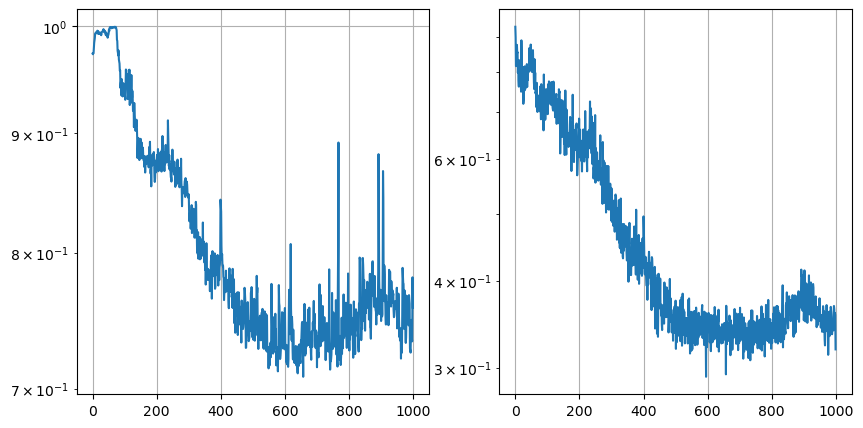

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.semilogy(log_loss)
plt.grid()
plt.subplot(122)
plt.semilogy(-log_rew)
plt.grid()
plt.show()  

In [9]:
params["params"]["std"]

Array(0.00611338, dtype=float64)

# Simulation with trained policy

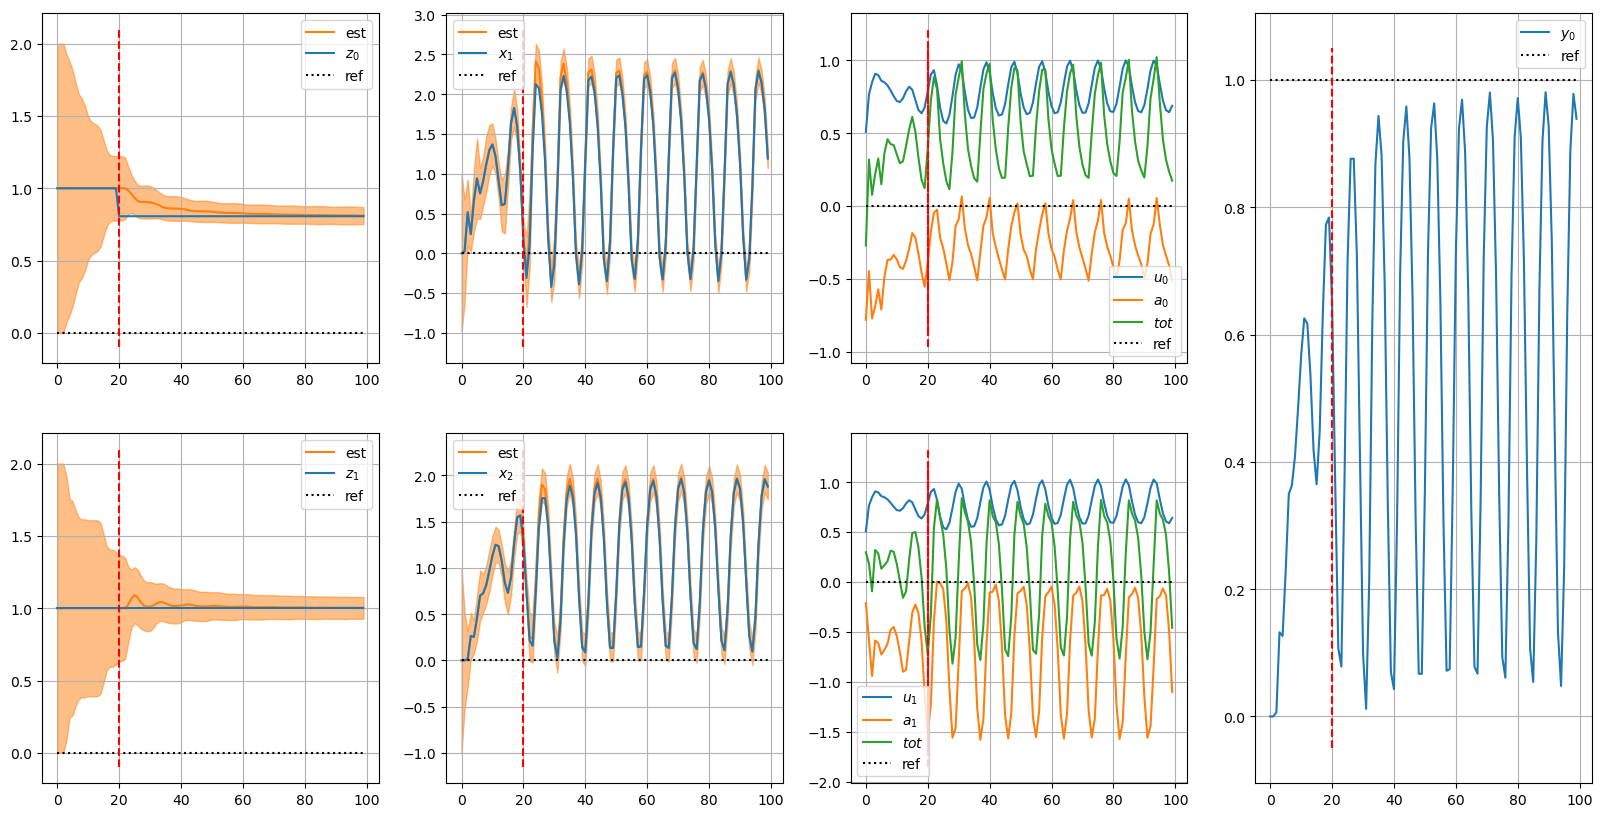

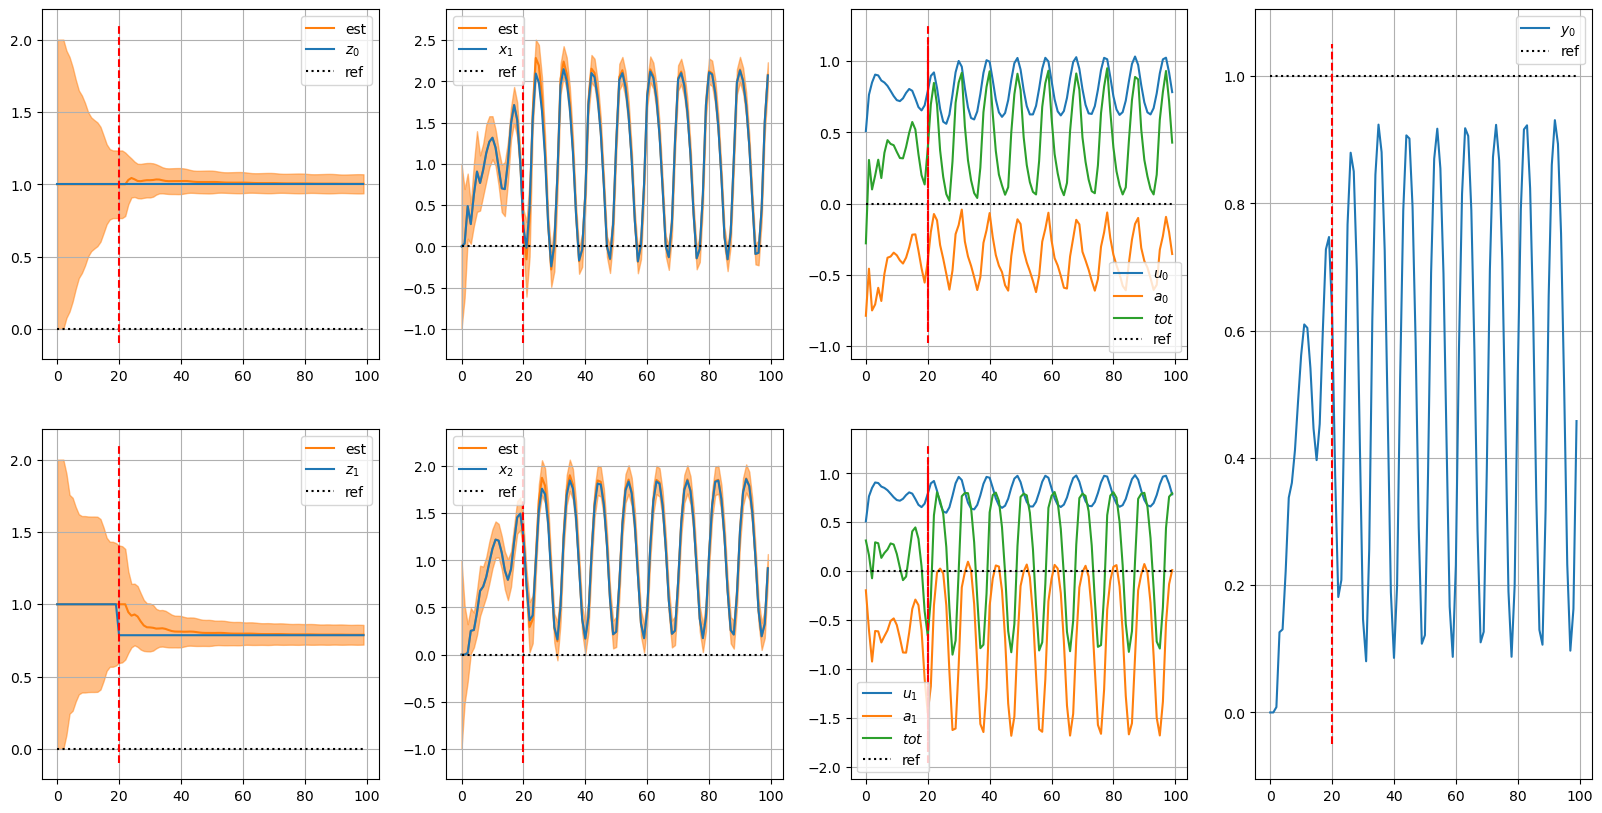

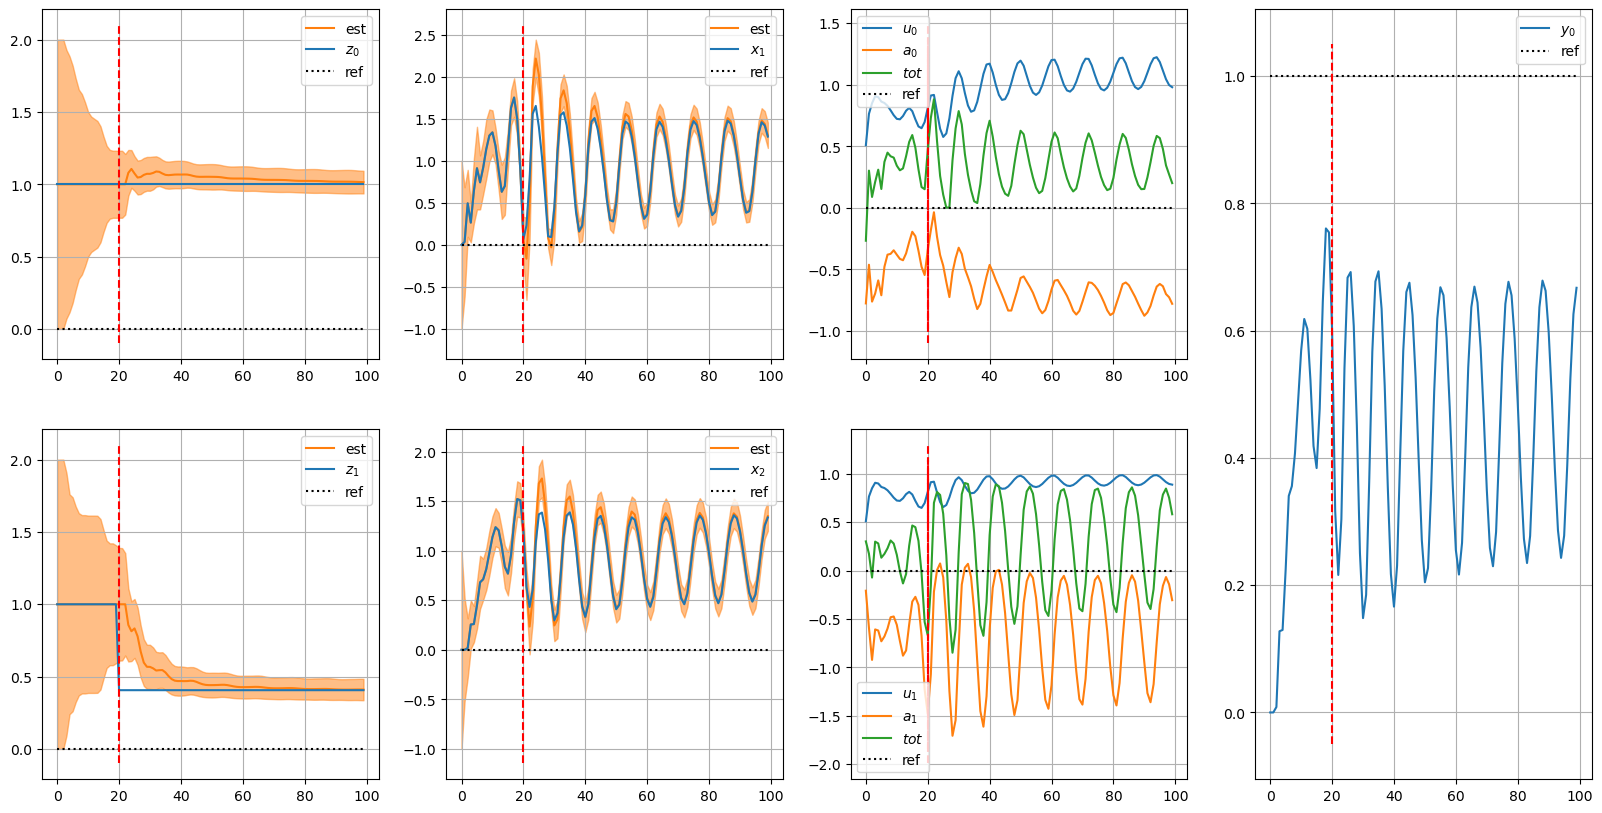

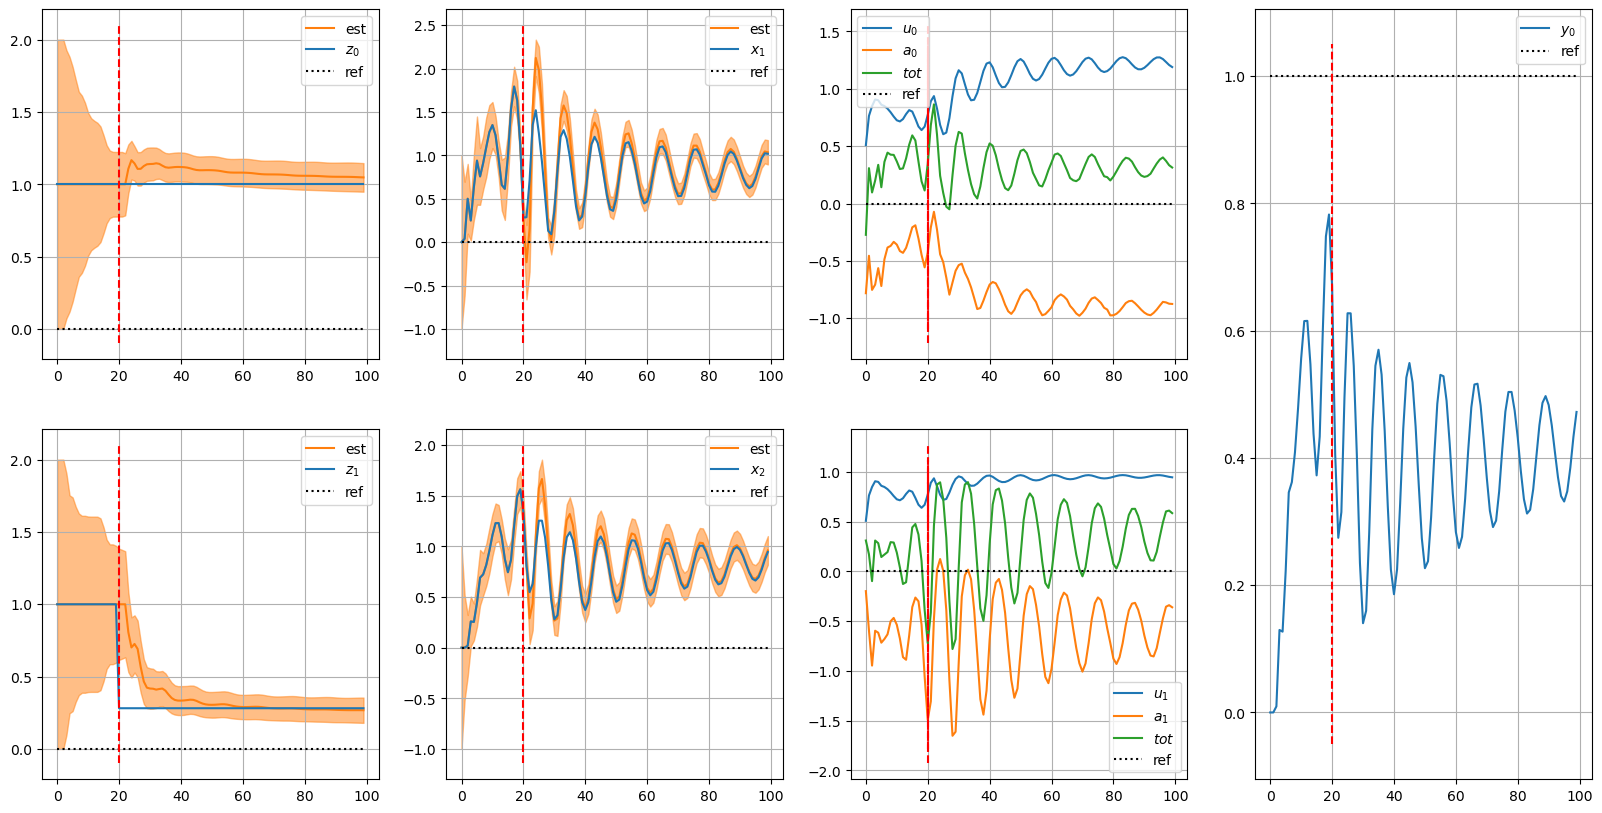

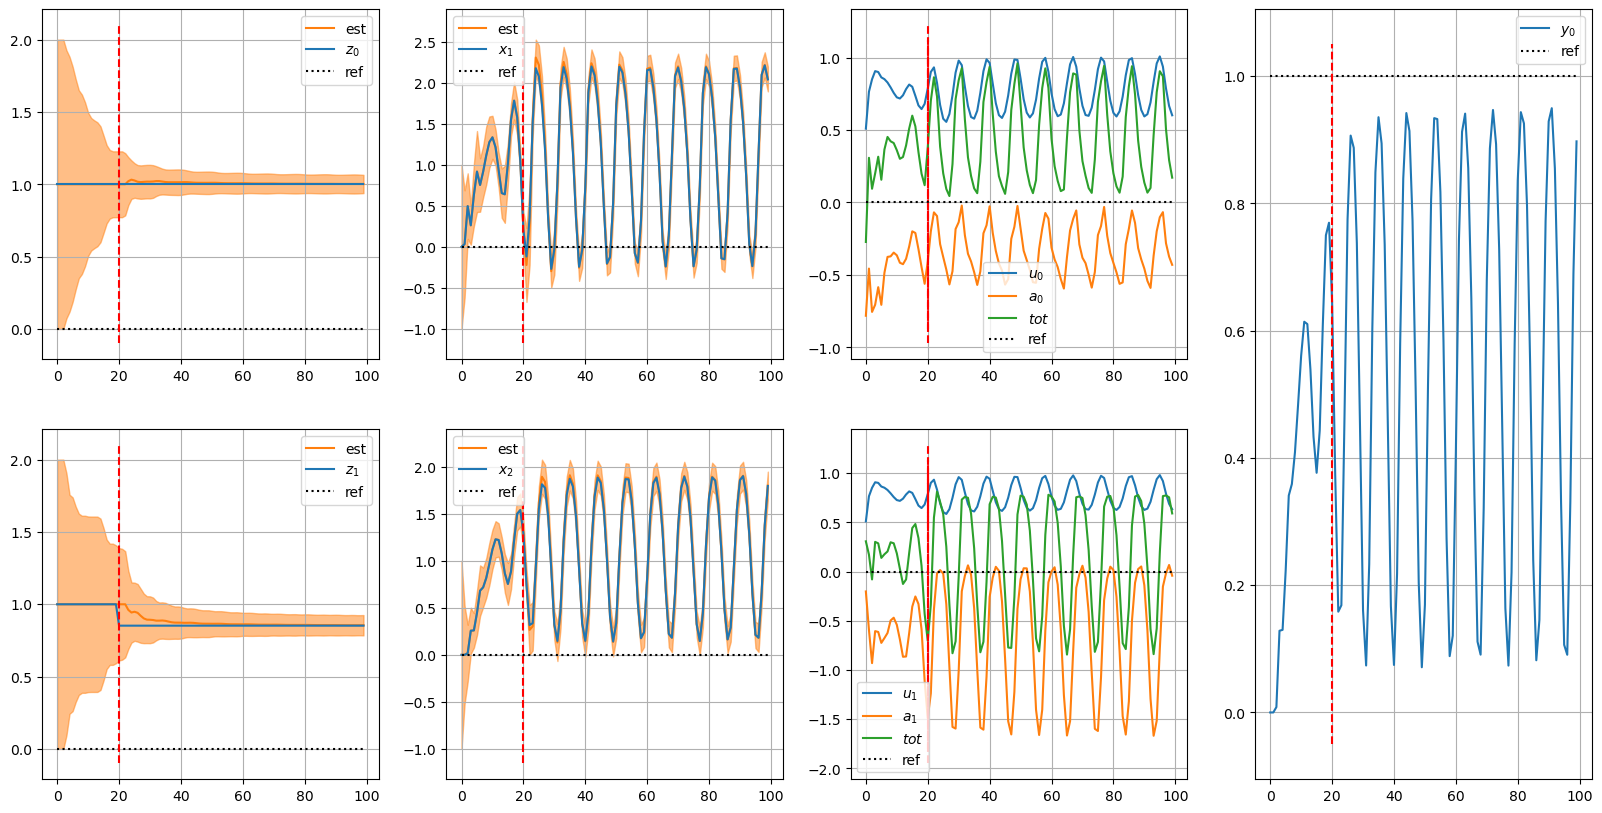

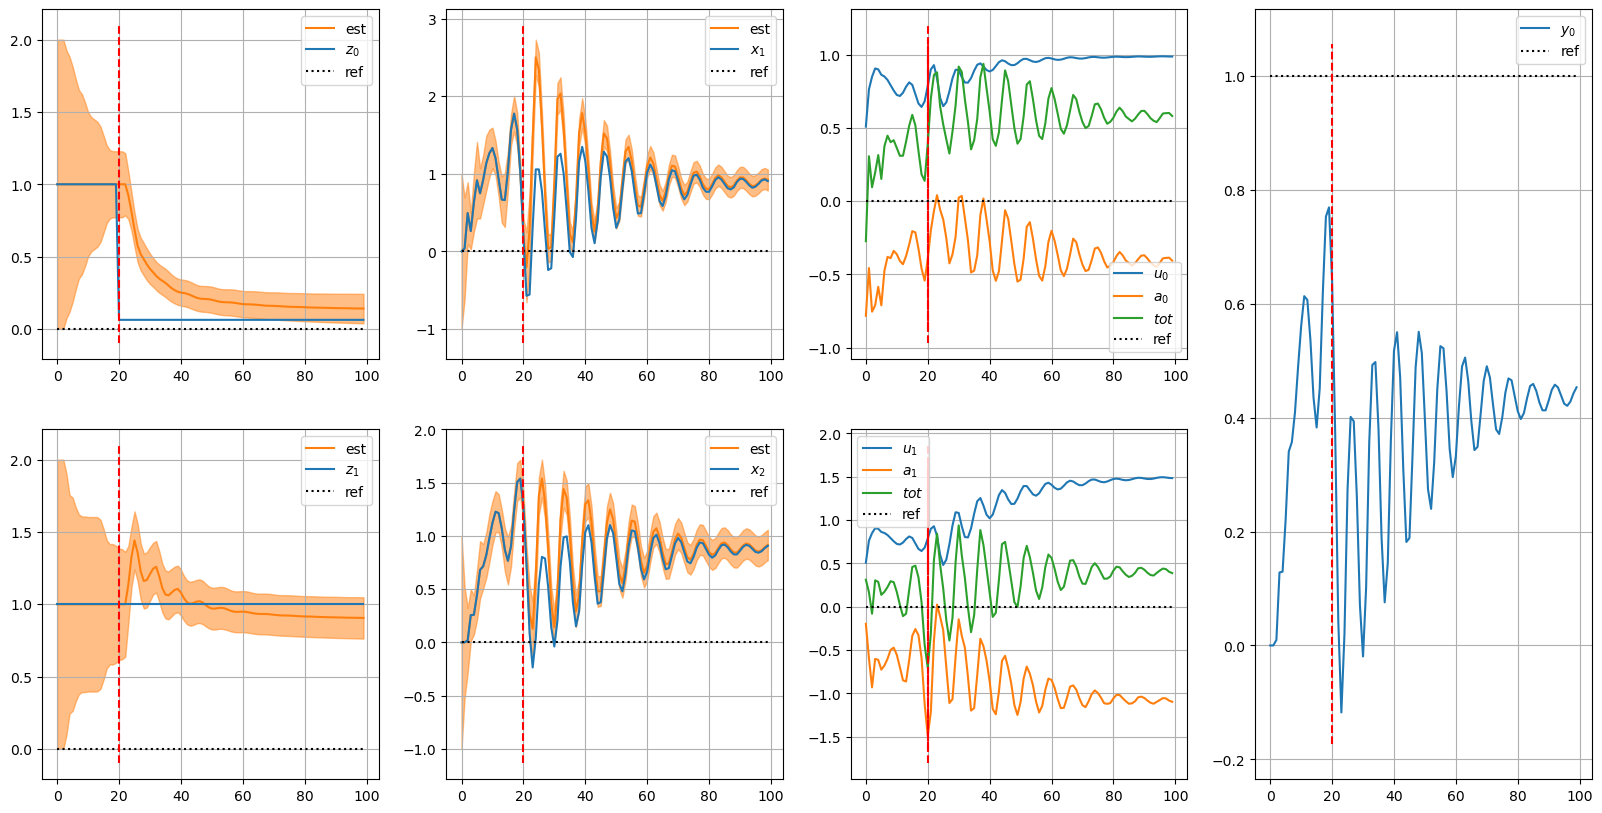

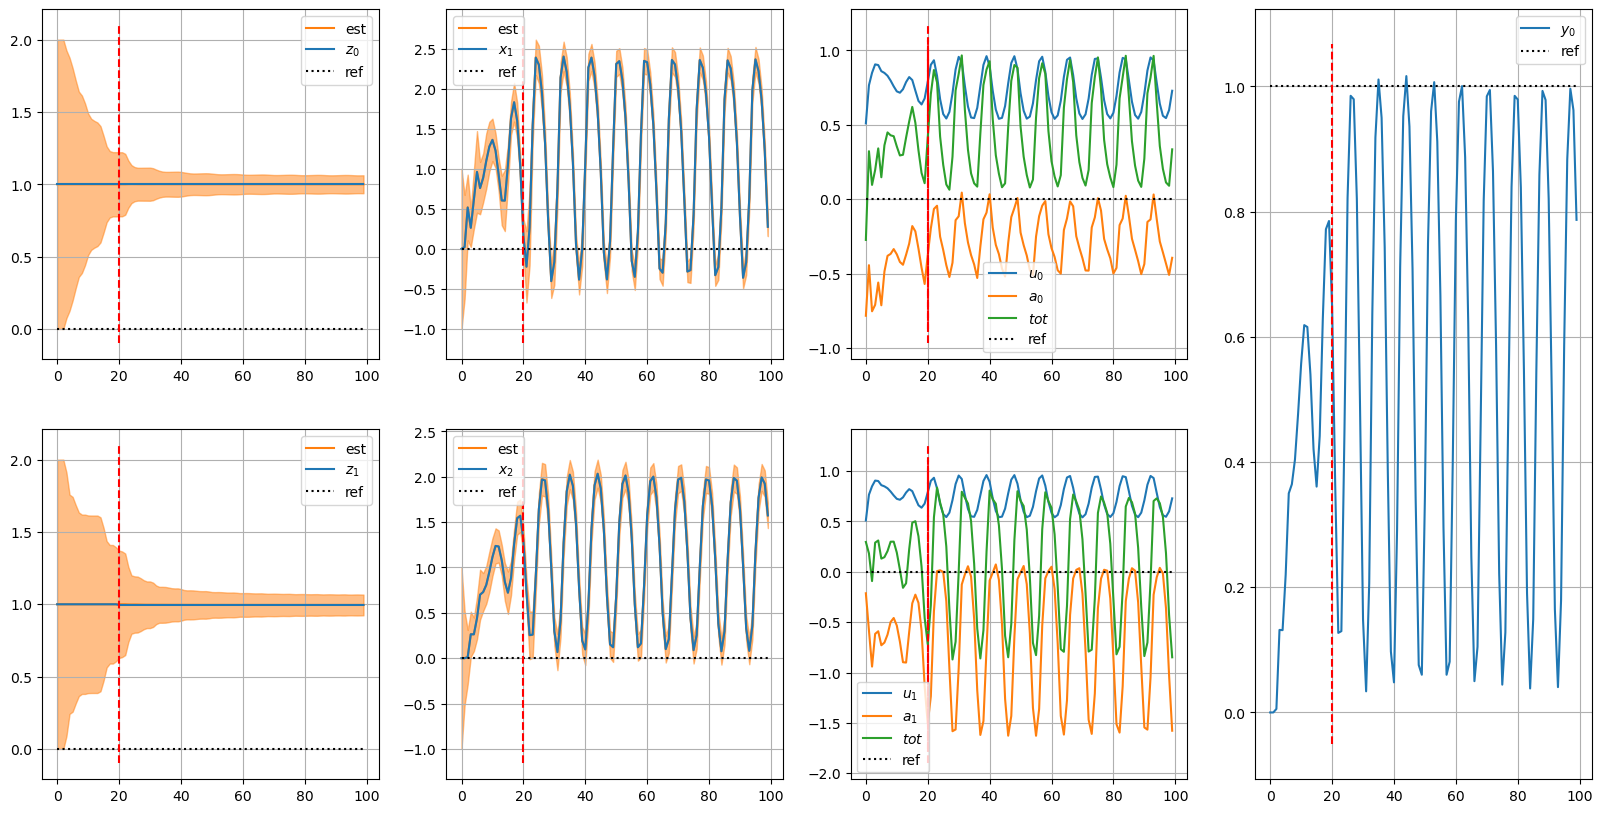

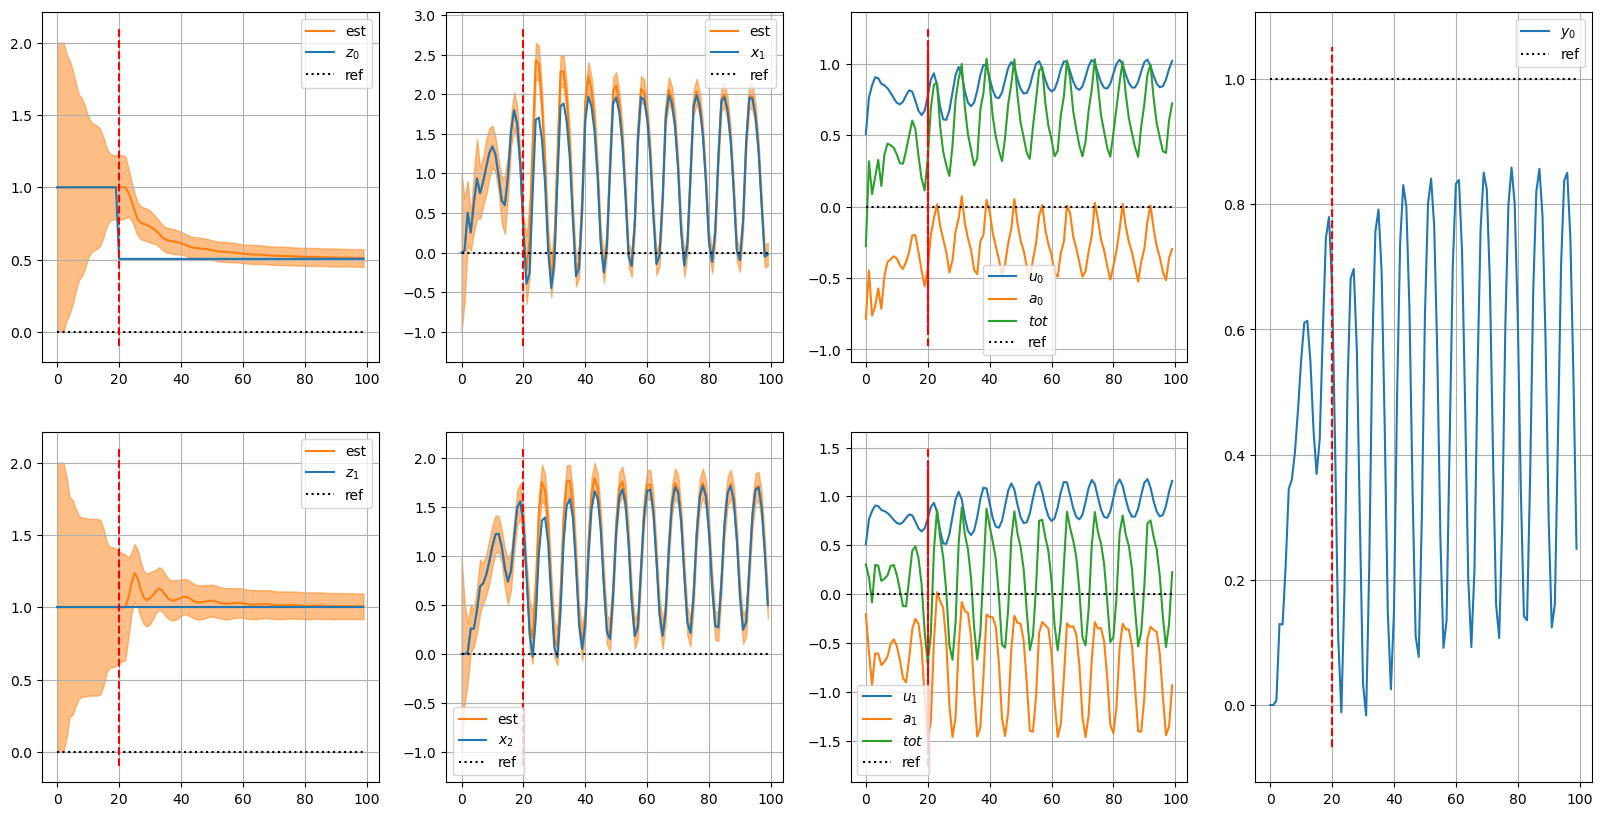

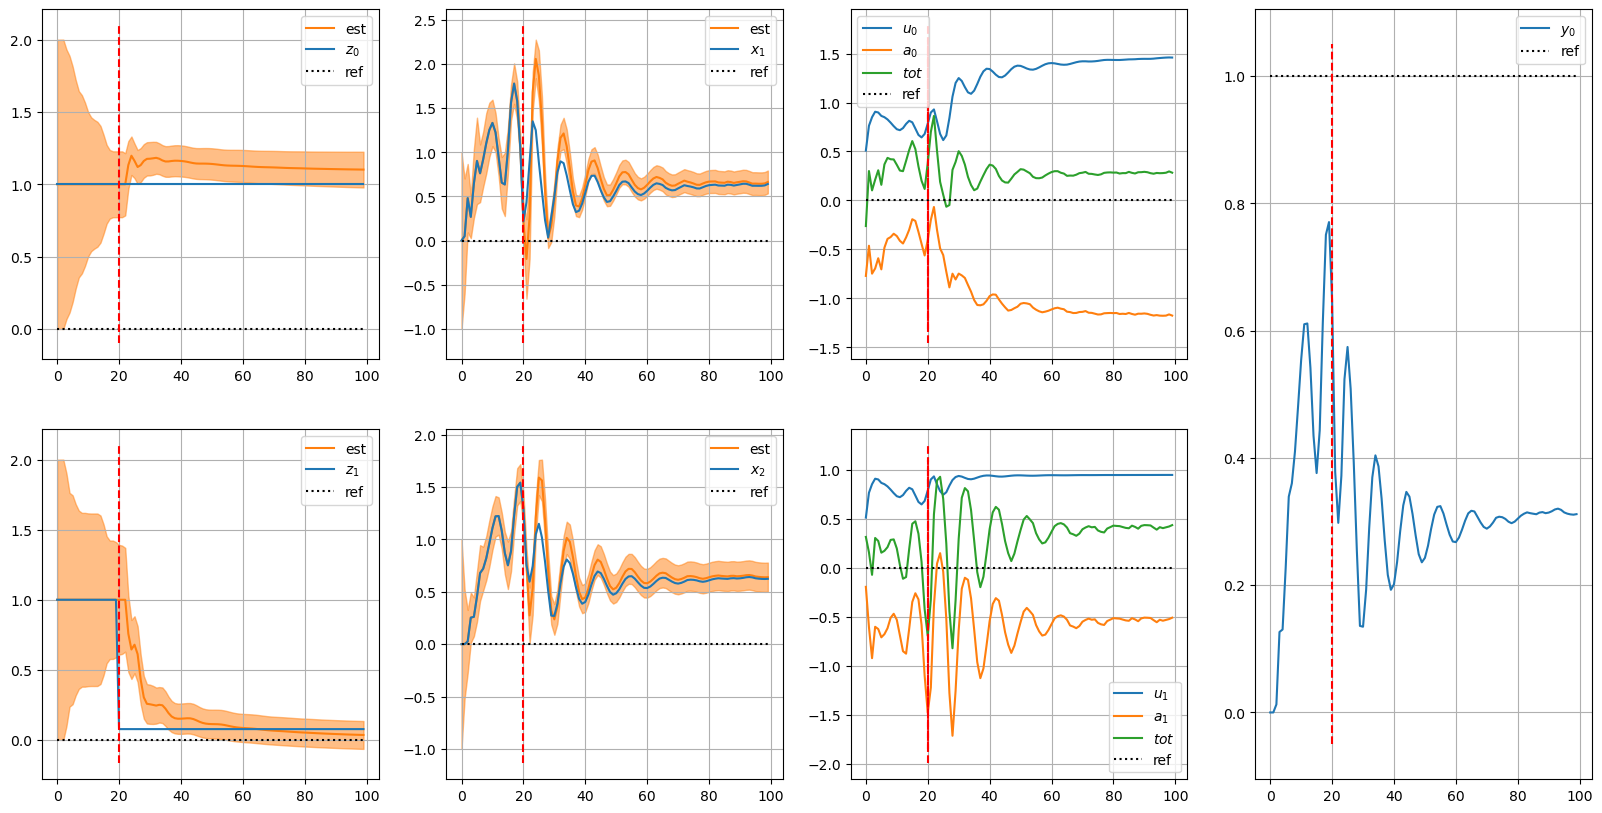

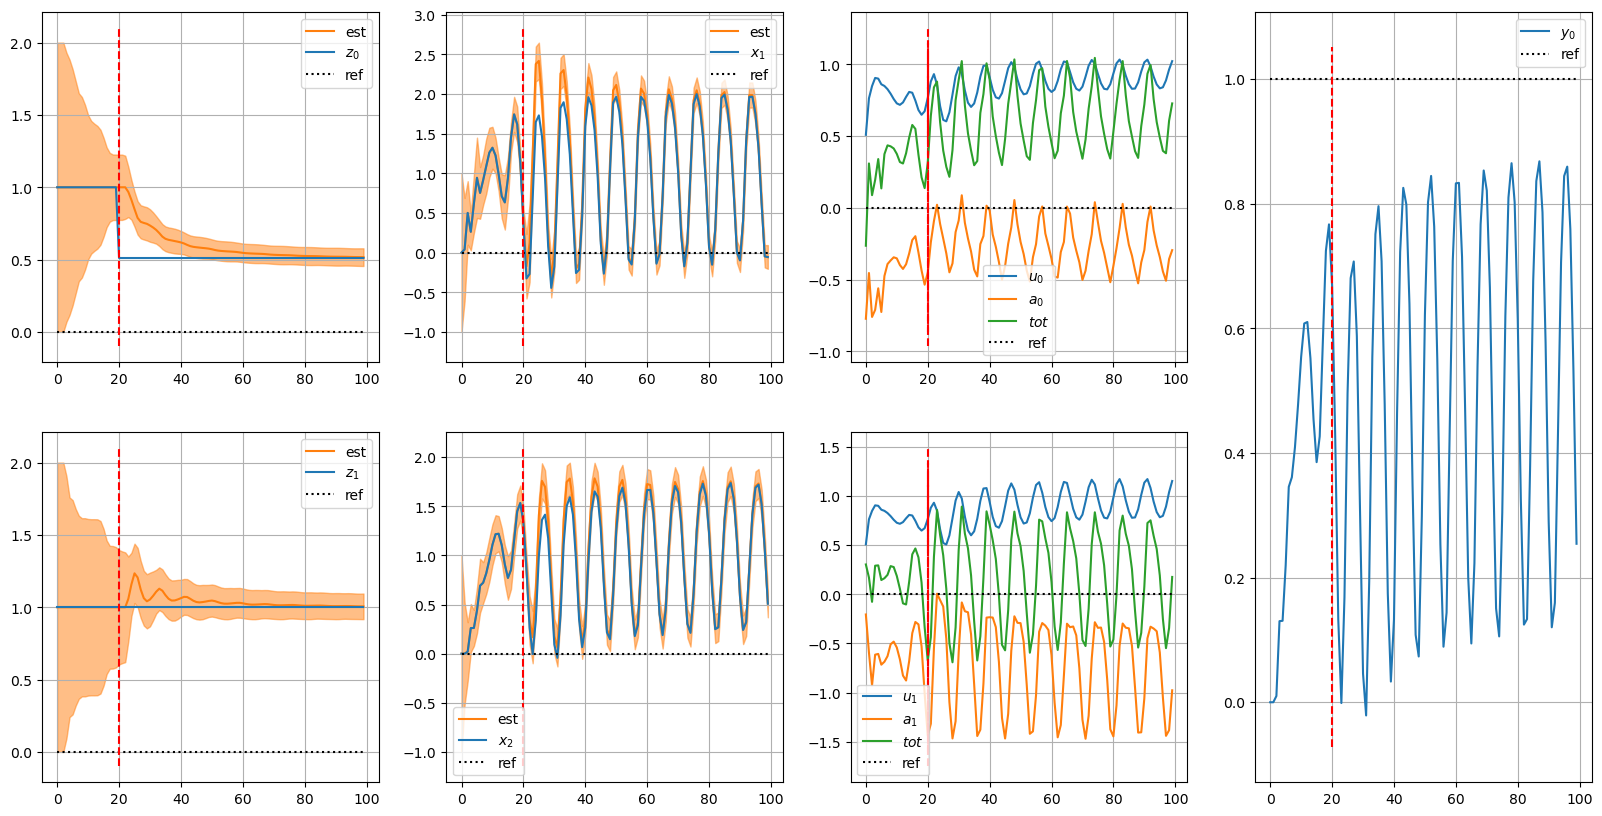

In [10]:
aux = partial(policy.apply, params, method="action")
for seed in range(10):
    state, outs, rewards = sim.rollout(aux, rng=jr.key(seed))
    sim.plot(outs)